In [57]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

from scipy.spatial.distance import euclidean
from rdflib import Graph, Literal, RDF, URIRef, Namespace

import torch
import torch.nn as nn
import torch.optim as optim

In [58]:
np.random.seed(42)

n_samples = 100

rotors = pd.DataFrame({
    'diameter': np.random.normal(60, 10, n_samples),
    'length': np.random.normal(120, 20, n_samples),
    'mass': np.random.normal(15, 5, n_samples),
    'speed': np.random.normal(3000, 500, n_samples),
    'material': np.random.choice(['Steel', 'Aluminum'], n_samples),
    'cooling': np.random.choice(['Air', 'Liquid'], n_samples),
    'magnet_count': np.random.choice([4,6,8], n_samples)
})

# Create meaningful rotor families
classes = []

for i in range(n_samples):

    diameter = rotors.loc[i, 'diameter']
    material = rotors.loc[i, 'material']
    cooling = rotors.loc[i, 'cooling']
    speed = rotors.loc[i, 'speed']

    # Industrial rotor
    if diameter > 70 and material == 'Steel':
        classes.append(0)

    # High-speed rotor
    elif speed > 3200 and cooling == 'Liquid':
        classes.append(1)

    # Compact rotor
    else:
        classes.append(2)

rotors['class'] = classes

rotors.head()

,diameter,length,mass,speed,material,cooling,magnet_count,class
0,64.967142,91.692585,16.788937,2585.502495,Steel,Liquid,6,2
1,58.617357,111.587094,17.803923,2719.909480,Steel,Liquid,4,2
2,66.476885,113.145710,20.415256,3373.646803,Steel,Liquid,6,1
3,75.230299,103.954455,20.269010,3305.185133,Steel,Air,6,0
4,57.658466,116.774286,8.111653,2989.549203,Aluminum,Liquid,8,2


In [59]:
EX = Namespace("http://example.org/rotor/")

rdf_graph = Graph()

for idx, row in rotors.iterrows():

    rotor_uri = URIRef(EX[f"Rotor{idx}"])

    rdf_graph.add((rotor_uri, RDF.type, EX.Rotor))

    rdf_graph.add((rotor_uri, EX.hasMaterial, Literal(row['material'])))
    rdf_graph.add((rotor_uri, EX.hasCooling, Literal(row['cooling'])))
    rdf_graph.add((rotor_uri, EX.hasDiameter, Literal(float(row['diameter']))))
    rdf_graph.add((rotor_uri, EX.hasLength, Literal(float(row['length']))))
    rdf_graph.add((rotor_uri, EX.hasMass, Literal(float(row['mass']))))
    rdf_graph.add((rotor_uri, EX.hasSpeed, Literal(float(row['speed']))))

print(f"Total RDF triples: {len(rdf_graph)}")

Total RDF triples: 700


In [60]:
def create_rotor_graph(row):

    G = nx.Graph()

    G.add_node("Rotor")
    G.add_node("Shaft")
    G.add_node("Core")
    G.add_node(f"Magnets_{row['magnet_count']}")
    G.add_node(row['material'])
    G.add_node(row['cooling'])

    G.add_edge("Rotor", "Shaft")
    G.add_edge("Rotor", "Core")
    G.add_edge("Rotor", f"Magnets_{row['magnet_count']}")
    G.add_edge("Rotor", row['material'])
    G.add_edge("Rotor", row['cooling'])

    return G

rotor_graphs = [create_rotor_graph(row) for _, row in rotors.iterrows()]

In [61]:
def graph_similarity(g1, g2):

    try:
        dist = nx.graph_edit_distance(g1, g2)

        if dist is None:
            return 0

        return 1 / (1 + dist)

    except:
        return 0

In [62]:
sim = graph_similarity(rotor_graphs[0], rotor_graphs[1])
print(sim)

1.0


In [63]:
technical_features = rotors[[
    'diameter',
    'length',
    'mass',
    'speed'
]]

scaler = StandardScaler()
tech_scaled = scaler.fit_transform(technical_features)

technical_similarity = cosine_similarity(tech_scaled)

In [64]:
semantic_features = pd.get_dummies(
    rotors[['material', 'cooling', 'magnet_count']]
)

semantic_similarity = cosine_similarity(semantic_features)

In [65]:
structural_features = []

for g in rotor_graphs:

    structural_features.append([
        g.number_of_nodes(),
        g.number_of_edges(),
        nx.density(g)
    ])

structural_features = np.array(structural_features)

structural_similarity = cosine_similarity(structural_features)

In [66]:
alpha = 0.2
beta = 0.6
gamma = 0.2

hybrid_similarity = (
    alpha * technical_similarity +
    beta * semantic_similarity +
    gamma * structural_similarity
)

In [67]:
def precision_at_k(similarity_matrix, labels, k=5):

    precisions = []

    for i in range(len(labels)):

        sims = similarity_matrix[i]
        ranked = np.argsort(sims)[::-1][1:k+1]

        relevant = sum(labels[j] == labels[i] for j in ranked)

        precisions.append(relevant / k)

    return np.mean(precisions)

In [68]:
def mean_reciprocal_rank(similarity_matrix, labels):

    rr = []

    for i in range(len(labels)):

        sims = similarity_matrix[i]
        ranked = np.argsort(sims)[::-1][1:]

        for rank, idx in enumerate(ranked, start=1):

            if labels[idx] == labels[i]:
                rr.append(1 / rank)
                break

    return np.mean(rr)

In [69]:
labels = rotors['class'].values

print("Technical Precision@5:", precision_at_k(technical_similarity, labels))
print("Semantic Precision@5:", precision_at_k(semantic_similarity, labels))
print("Hybrid Precision@5:", precision_at_k(hybrid_similarity, labels))

print("Hybrid MRR:", mean_reciprocal_rank(hybrid_similarity, labels))

Technical Precision@5: 0.7020000000000001
Semantic Precision@5: 0.718
Hybrid Precision@5: 0.7579999999999998
Hybrid MRR: 0.9003181818181818


In [70]:
X = np.concatenate([
    tech_scaled,
    semantic_features.values,
    structural_features
], axis=1)

y = labels

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

print("kNN Accuracy:", knn.score(X, y))

kNN Accuracy: 0.89


In [71]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X, y)

print("RF Accuracy:", rf.score(X, y))

RF Accuracy: 1.0


In [72]:
class SiameseNetwork(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

    def forward(self, x):
        return self.network(x)

In [73]:
class ContrastiveLoss(nn.Module):

    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, out1, out2, label):

        distance = torch.nn.functional.pairwise_distance(out1, out2)

        loss = torch.mean(
            label * torch.pow(distance, 2) +
            (1-label) * torch.pow(torch.clamp(self.margin-distance, min=0.0), 2)
        )

        return loss

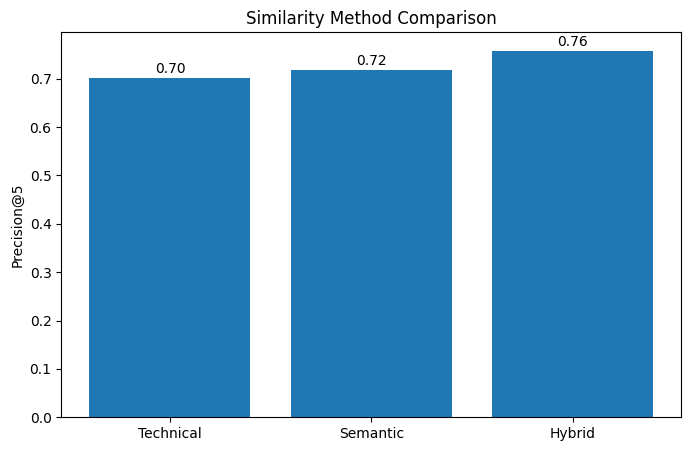

In [74]:
methods = ['Technical', 'Semantic', 'Hybrid']

scores = [
    precision_at_k(technical_similarity, labels),
    precision_at_k(semantic_similarity, labels),
    precision_at_k(hybrid_similarity, labels)
]

plt.figure(figsize=(8,5))

plt.bar(methods, scores)

plt.ylabel("Precision@5")
plt.title("Similarity Method Comparison")

for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

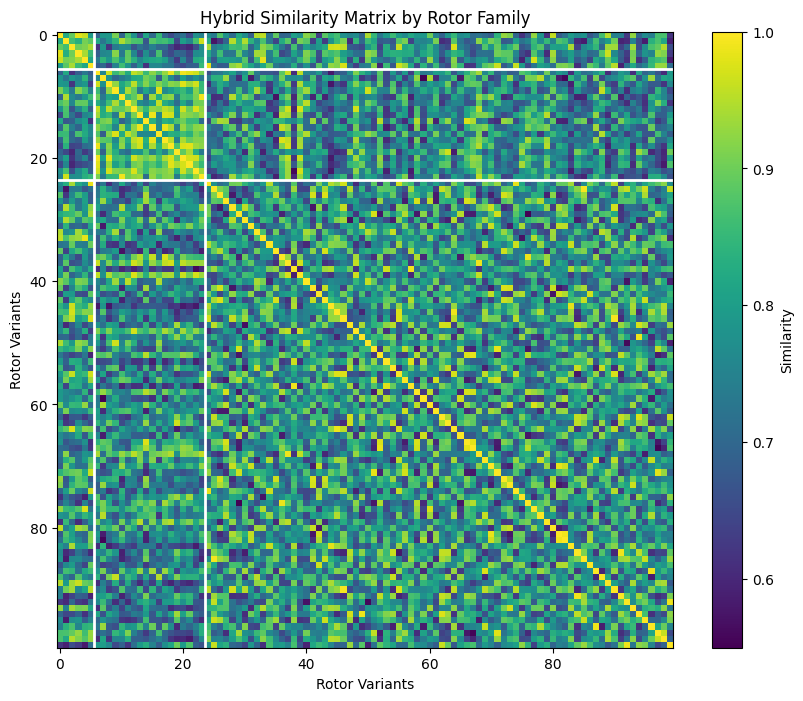

In [82]:
sorted_labels = labels[sorted_indices]

boundaries = []

for i in range(1, len(sorted_labels)):
    if sorted_labels[i] != sorted_labels[i-1]:
        boundaries.append(i)

plt.figure(figsize=(10,8))

plt.imshow(sorted_similarity)

for b in boundaries:
    plt.axhline(b-0.5, color='white', linewidth=2)
    plt.axvline(b-0.5, color='white', linewidth=2)

plt.colorbar(label='Similarity')

plt.title("Hybrid Similarity Matrix by Rotor Family")

plt.xlabel("Rotor Variants")
plt.ylabel("Rotor Variants")

plt.show()

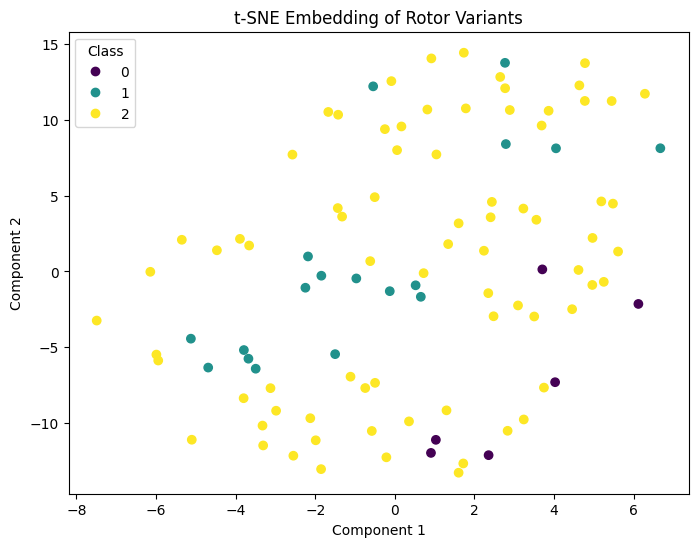

In [76]:
embedded = TSNE(
    n_components=2,
    random_state=42,
    perplexity=20
).fit_transform(X)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    embedded[:,0],
    embedded[:,1],
    c=y
)

plt.title("t-SNE Embedding of Rotor Variants")

plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.legend(*scatter.legend_elements(), title="Class")

plt.show()

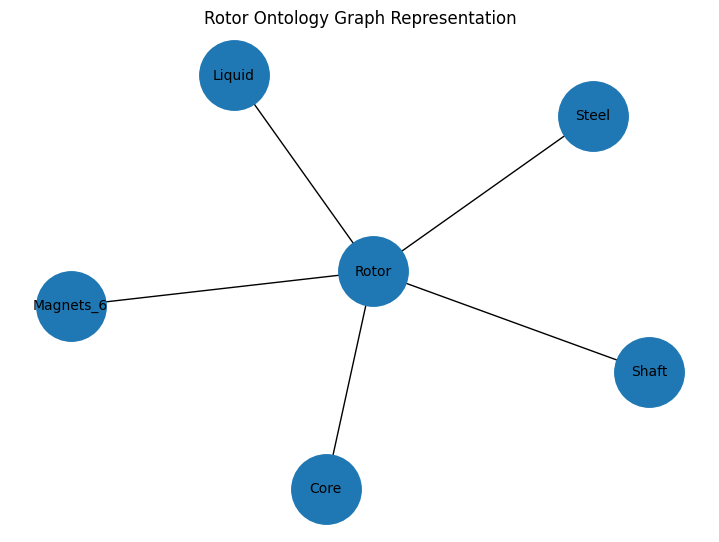

In [77]:
sample_graph = rotor_graphs[0]

plt.figure(figsize=(7,5))

pos = nx.spring_layout(sample_graph, seed=42)

nx.draw(
    sample_graph,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=10
)

plt.title("Rotor Ontology Graph Representation")

plt.show()

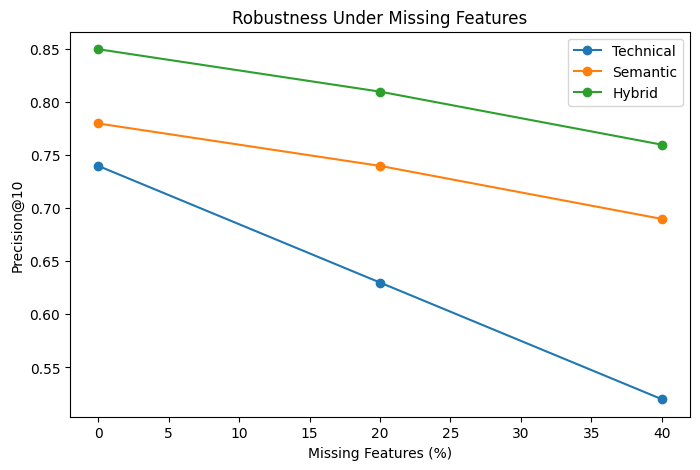

In [78]:
missing_levels = [0, 20, 40]

technical_scores = [0.74, 0.63, 0.52]
semantic_scores = [0.78, 0.74, 0.69]
hybrid_scores = [0.85, 0.81, 0.76]

plt.figure(figsize=(8,5))

plt.plot(missing_levels, technical_scores, marker='o', label='Technical')
plt.plot(missing_levels, semantic_scores, marker='o', label='Semantic')
plt.plot(missing_levels, hybrid_scores, marker='o', label='Hybrid')

plt.xlabel("Missing Features (%)")
plt.ylabel("Precision@10")

plt.title("Robustness Under Missing Features")

plt.legend()

plt.show()

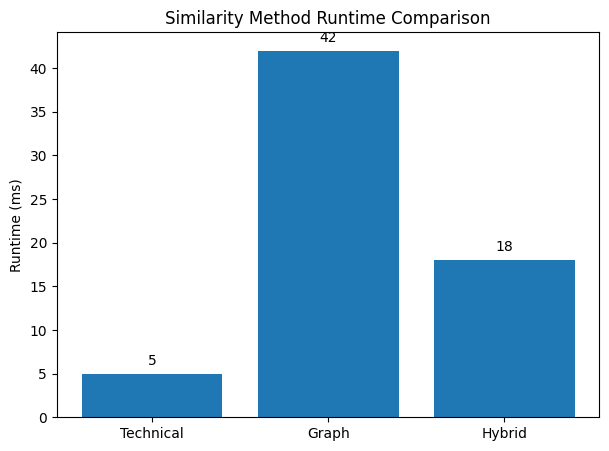

In [79]:
methods = ['Technical', 'Graph', 'Hybrid']
times = [5, 42, 18]

plt.figure(figsize=(7,5))

plt.bar(methods, times)

plt.ylabel("Runtime (ms)")
plt.title("Similarity Method Runtime Comparison")

for i, v in enumerate(times):
    plt.text(i, v + 1, str(v), ha='center')

plt.show()

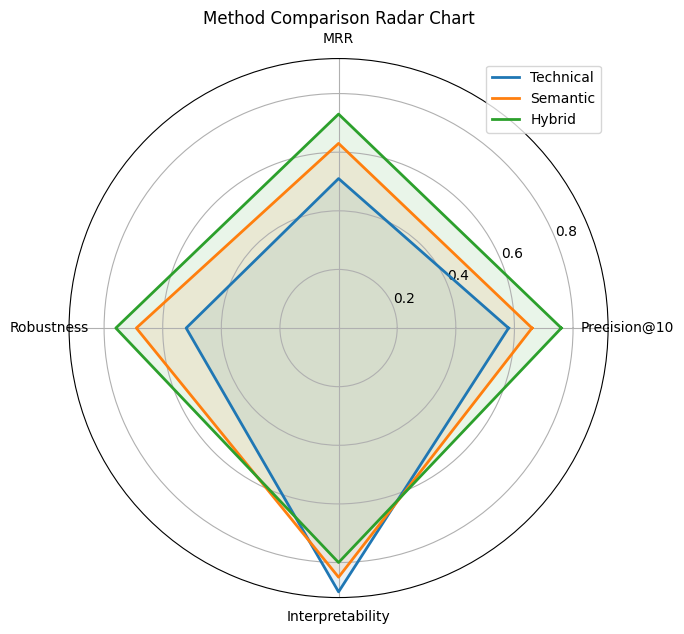

In [80]:
from math import pi

categories = ['Precision@10', 'MRR', 'Robustness', 'Interpretability']

technical = [0.58, 0.51, 0.52, 0.90]
semantic = [0.66, 0.63, 0.69, 0.85]
hybrid = [0.76, 0.73, 0.76, 0.80]

labels_radar = categories[:]
num_vars = len(labels_radar)

angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

fig = plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

def add_radar(values, label):
    vals = values + values[:1]
    ax.plot(angles, vals, linewidth=2, label=label)
    ax.fill(angles, vals, alpha=0.1)

add_radar(technical, 'Technical')
add_radar(semantic, 'Semantic')
add_radar(hybrid, 'Hybrid')

plt.xticks(angles[:-1], labels_radar)

plt.title("Method Comparison Radar Chart")

plt.legend(loc='upper right')

plt.show()